## Imports

In [1]:
import sys
import os

module_path = os.path.abspath(os.path.join('..', 'src'))
sys.path.insert(0, module_path)

In [2]:
import pandas as pd
import plotly.express as px
import numpy as np
import json

from src.analysis.converters import convert_transitions_to_state_counts, convert_transitions_to_agent_states
from src.models.seir import SEIRNeighborsFSMAgent

## Load data

In [7]:
sim_dt = "2025-10-07-005539Z"
sim_data_filename = f"../simulation_data/research/SEIR_Neighbors_Simulation_Transitions-{sim_dt}.csv"
sim_params_filename = f"../simulation_data/research/SEIR_Neighbors_Simulation_Params-{sim_dt}.json"
neighbors = pd.read_csv(
    "../simulation_conditions_data/neighbors/NeighborsMap-100by100-Agents1000-Neighbors20-2025-10-02-225806Z.csv"
)

In [8]:
with open(sim_params_filename, "r") as file:
    sim_params = json.load(file)
sim_params

{'random_seed': 42,
 'n_agents': 10000,
 'sim_duration': 365,
 'output_path': 'simulation_data',
 'initially_infected': 5,
 'beta': 0.01,
 'gamma': 0.01,
 'sigma': 0.05,
 'e1': 5,
 'e2': 10,
 't1': 14,
 't2': 21,
 'simulation_start': '2025-10-07-005412Z',
 'simulation_end': '2025-10-07-005539Z',
 'simulation_duration_seconds': 87.135305,
 'agent_class': 'SEIRNeighborsFSMAgent'}

In [9]:
transitions_df = pd.read_csv(sim_data_filename)
transitions_df.head()

,time,agent,event,source_state,dest_state
0,0,1824,transition,susceptible,infected
1,0,409,transition,susceptible,infected
2,0,4506,transition,susceptible,infected
3,0,4012,transition,susceptible,infected
4,0,3657,transition,susceptible,infected


In [10]:
states = [state.name for state in SEIRNeighborsFSMAgent.states]

In [11]:
state_counts_df = convert_transitions_to_state_counts(transitions_df=transitions_df,
                                                       states=states,
                                                       initial_state=states[0],
                                                       n_agents=sim_params['n_agents'],
                                                       sim_duration=sim_params['sim_duration'])

## Simulation Params

In [12]:
N_AGENTS = sim_params['n_agents']
BETA = sim_params['beta']
GAMMA = sim_params['gamma']
SIM_DURATION = sim_params['sim_duration']

## Visualization

### Style

In [13]:
color_map = {"susceptible": "#8da0cb", "infected": "#fc8d62", "recovered": "#66c2a5"}
title_text = f"SEIR Neighbor Agent Model<br>β={BETA}, γ={GAMMA}, Population Size={N_AGENTS}"

legend_params = dict(
    orientation="h",
    yanchor="bottom",
    y=-.3,
    xanchor="center",
    x=0.5,
    title_text="")

title_params = dict(text=title_text, font_size=20)

graph_params = dict(
    title=title_params,
    legend=legend_params,
    width=1000,
    height=500,
    template="presentation")

### Area Plot

In [14]:
groups = [g for g in state_counts_df.columns if g != 'time']

timeline_df = (
    state_counts_df
    .melt(id_vars=['time'], value_vars=groups, var_name="grp", value_name="count")
    .assign(grp=lambda _df: pd.Categorical(_df.grp, categories=groups, ordered=True))
    .sort_values(by=["time", "grp"], ascending=[True, False])
    .reset_index(drop=True)
)
timeline_df.head(5)

,time,grp,count
0,0,recovered,0
1,0,infected,5
2,0,exposed,0
3,0,susceptible,9995
4,1,recovered,0


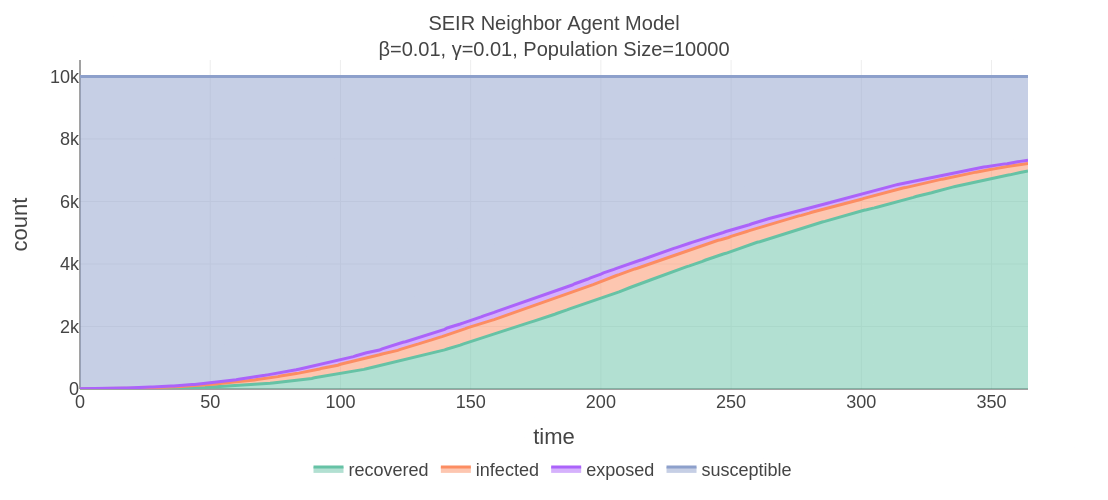

In [15]:
fig = px.area(timeline_df, x="time", y="count", color="grp", color_discrete_map=color_map)
fig.update_layout(**graph_params)
fig.show()

### Line Plot

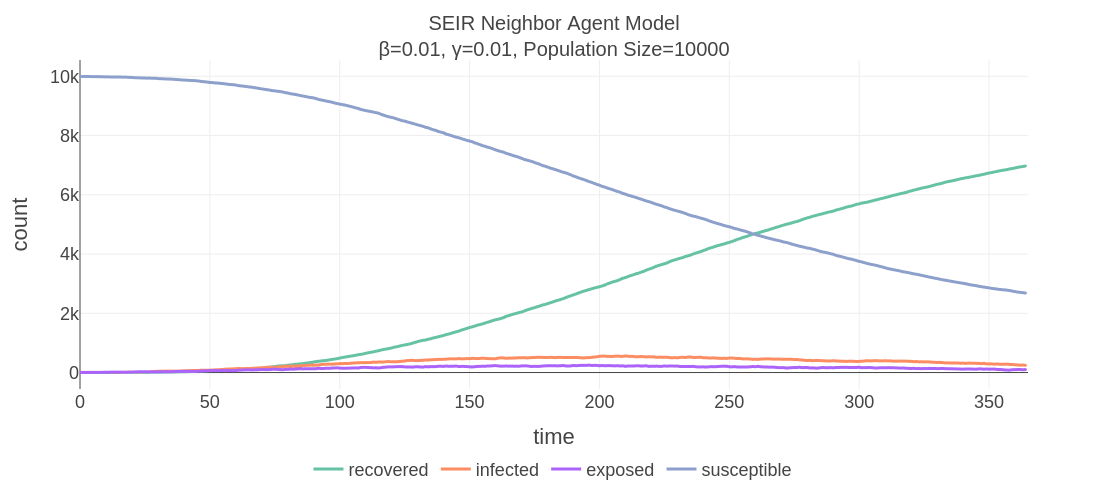

In [16]:
fig = px.line(timeline_df, x="time", y="count", color="grp", color_discrete_map=color_map)
fig.update_layout(**graph_params, xaxis_range=[0, 365])
fig.show()

### Line plot animated

In [21]:
df2 = (
    state_counts_df
    .sort_values(by=["time"])
    .reset_index(drop=True)
    .head(365)
)

In [22]:
def create_animation_df(source_df, start=10, frame_cnt=SIM_DURATION, speed_up=1):
    target_df = pd.DataFrame()
    frame_cnt = int(frame_cnt / speed_up)
    for i in np.arange(start, frame_cnt):
        dfa = source_df.head(i * speed_up).copy()
        dfa['ix'] = i
        target_df = pd.concat([target_df, dfa])
    return target_df

In [23]:
animation_df = create_animation_df(df2, start=0, frame_cnt=df2.shape[0], speed_up=1)

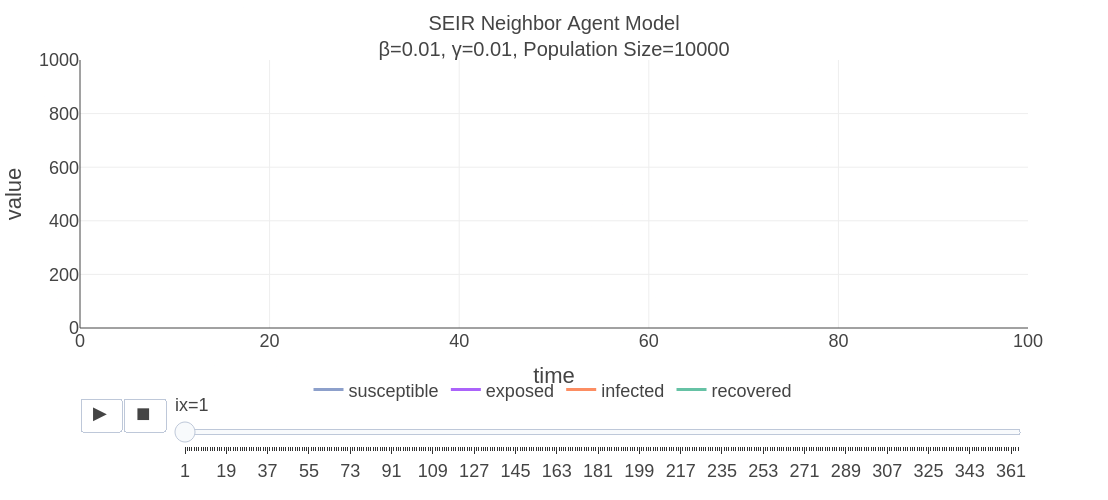

In [24]:
fig = px.line(animation_df,
              x="time",
              y=groups,
              animation_frame="ix",
              color_discrete_map=color_map)
fig.update_layout(**graph_params, xaxis_range=[0, 100], yaxis_range=[0, 1000])
fig.layout.updatemenus[0].buttons[0]['args'][1]['frame']['redraw'] = True
fig.show()

### Plane Plot

In [100]:
agent_states_df = convert_transitions_to_agent_states(transitions_df=transitions_df,
                                                       states=states,
                                                       initial_state=states[0],
                                                       n_agents=sim_params['n_agents'],
                                                       sim_duration=sim_params['sim_duration'])
agent_states_df['state'] = agent_states_df['state'].map(state_map)
agent_states_df.state = pd.Categorical(agent_states_df.state, states, ordered=True)

In [101]:
neighbors = neighbors[['x', 'y']]
neighbors = neighbors.reset_index()
neighbors.columns = ['agent', 'x', 'y']

In [102]:
agent_states_df = agent_states_df.merge(neighbors, on='agent', how='left')

In [105]:
def save_frames(df, frames, states, path, colormap, scale=1.0, width=500, height=400, legend_font_size=15, marker_size=4, ):
    for frame in range(frames):
        plane_at_time = df[df.time == frame]
        legend_entry = pd.DataFrame([
            {"time": frame, "agent": np.nan, "state": state, "x": np.nan, "y": np.nan} for state in states
        ])
        plane_at_time = pd.concat([legend_entry, plane_at_time])
        
        fig = px.scatter(plane_at_time,
                     x="x",
                     y="y", 
                     color="state",  
                     color_discrete_map=colormap)
        fig.update_traces(marker=dict(size=marker_size))
                     

        fig.update_layout(
            legend=dict(title_text='', 
                        font_size=legend_font_size,
                        orientation="h",
                        xanchor="center",
                        x=0.5,
                        yanchor="top",
                        y=1.1),
            margin=dict(l=40, r=40, t=40, b=40),
            width=width, 
            height=height,
            template='presentation')
        fig.write_image(f"{path}/frame_{frame:03d}.png", scale=scale)

In [108]:
save_frames(agent_states_df, 
            states=states,
            frames=70, 
            path="../gif_data", 
            marker_size=5, 
            colormap={'susceptible': "#8da0cb", 'infected': "#fc8d62", 'recovered': "#66c2a5"})